# Signal quality report

Load a recording by path, compute quality metrics over a grid of **1-second
windows**, apply filters, and report **which channels are bad and when**.

The unit of judgement is the `(channel, interval)` cell, not the channel. A
channel that is clean for 25 minutes and unusable for 3 gets a different answer
per second, and the deliverable is a set of segments to exclude — *"drop C3 from
412 s to 438 s"* — rather than a list of condemned electrodes.

| stage | what it does | what it does *not* do |
|---|---|---|
| `load` | path → `Recording` (xarray) | interpret anything |
| `compute` | metrics → one joined table, per (channel, interval) | decide what is bad |
| `apply_filters` | table → flags | recompute anything |
| `verdict` / `bad_segments` | flags → time spans to exclude | hide what it excluded |

## Two scales, deliberately

Quality faults come at two scales and neither subsumes the other:

* **Channel-scope.** An attenuated or isolated electrode is abnormal relative to
  the other channels *over the whole recording*. Per second this is nearly
  invisible — on the reference study an electrode attenuated to a third of its
  neighbours scores a robust z of −8.9 over the recording but a median of only
  −1.2 per second, because the spread across channels within any one second is
  far wider than the spread of their whole-recording averages.
* **Time-scope.** Movement, a lead pulled loose, a transient saturation. A
  whole-recording summary averages these away into a channel that looks merely
  mediocre.

`sq.assess()` runs both and labels every finding with its `scope`.

## The example in this notebook

By default this runs on a **synthetic recording** carrying a known fault of
every kind — sustained ones *and* episodes bounded in time — with time-resolved
ground truth, so §5 scores detection instead of asking you to eyeball it.
Set `USE_SYNTHETIC = False` and point `STUDY` at a real recording to use one.

> **Data stays outside this repo.** Clear outputs or de-identify before sharing:
> channel names and annotations can carry identifying information.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import signal_quality as sq
from signal_quality import metrics as M

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.width", 200)

USE_SYNTHETIC = True
STUDY = Path("~/Documents/remy_eeg_northwell_2026-06-23/eeg_open_source/remy_eeg_lossless.h5").expanduser()
LINE_FREQ = 60.0   # 60 in the Americas, 50 across most of the rest of the world
WINDOW = 1.0       # flagging resolution, seconds

## 1. Load

In [2]:
if USE_SYNTHETIC:
    rec, truth = sq.make_demo_recording(line_freq=LINE_FREQ)
    print("synthetic demo recording with known, time-resolved injected faults")
else:
    rec, truth = sq.load(STUDY, line_freq=LINE_FREQ), None

print(rec)
print("raw counts available:", rec.has_counts)
print("stamp tables available:", "stamps" in rec.provenance)
rec.ds

synthetic demo recording with known, time-resolved injected faults
<Recording 30 ch @ 250 Hz, 3.0 min, 87% covered, counts>
raw counts available: True
stamp tables available: True


<xarray.Dataset> Size: 17MB
Dimensions:    (channel: 30, time: 45000)
Coordinates:
  * channel    (channel) <U4 480B 'Fp1' 'Fp2' 'F3' 'F4' ... 'A2' 'ECGL' 'OSAT'
    ch_type    (channel) <U4 480B 'eeg' 'eeg' 'eeg' 'eeg' ... 'eeg' 'ecg' 'misc'
    ch_unit    (channel) <U2 240B 'uV' 'uV' 'uV' 'uV' ... 'uV' 'uV' 'uV' 'uV'
    factor_uV  (channel) float64 240B 0.2658 0.2658 0.2658 ... 0.2658 0.2658
  * time       (time) float64 360kB 0.0 0.004 0.008 0.012 ... 180.0 180.0 180.0
Data variables:
    signal     (channel, time) float64 11MB -1.143e-05 -1.01e-05 ... 0.0 0.0
    counts     (channel, time) int32 5MB -43 -38 -33 -34 -41 -36 ... 0 0 0 0 0 0
    covered    (time) bool 45kB True True True True True ... True True True True
Attributes:
    sfreq:      250.0
    line_freq:  60.0
    meas_date:

## 1.1 Look at the raw signals first

Before any metric runs. Every number later is a summary, and summaries only
answer questions you already thought to ask.

Each pixel column shows the **min–max envelope** of the samples it covers, not a
decimated sample — plain decimation would drop exactly the brief excursions that
are most diagnostic. Traces are clipped to their lane, and any channel that
overruns it is named underneath with its true peak. Where channel types are
mixed, lanes are in each channel's own SD, because EEG in µV and a DC channel in
device units cannot share an absolute scale.

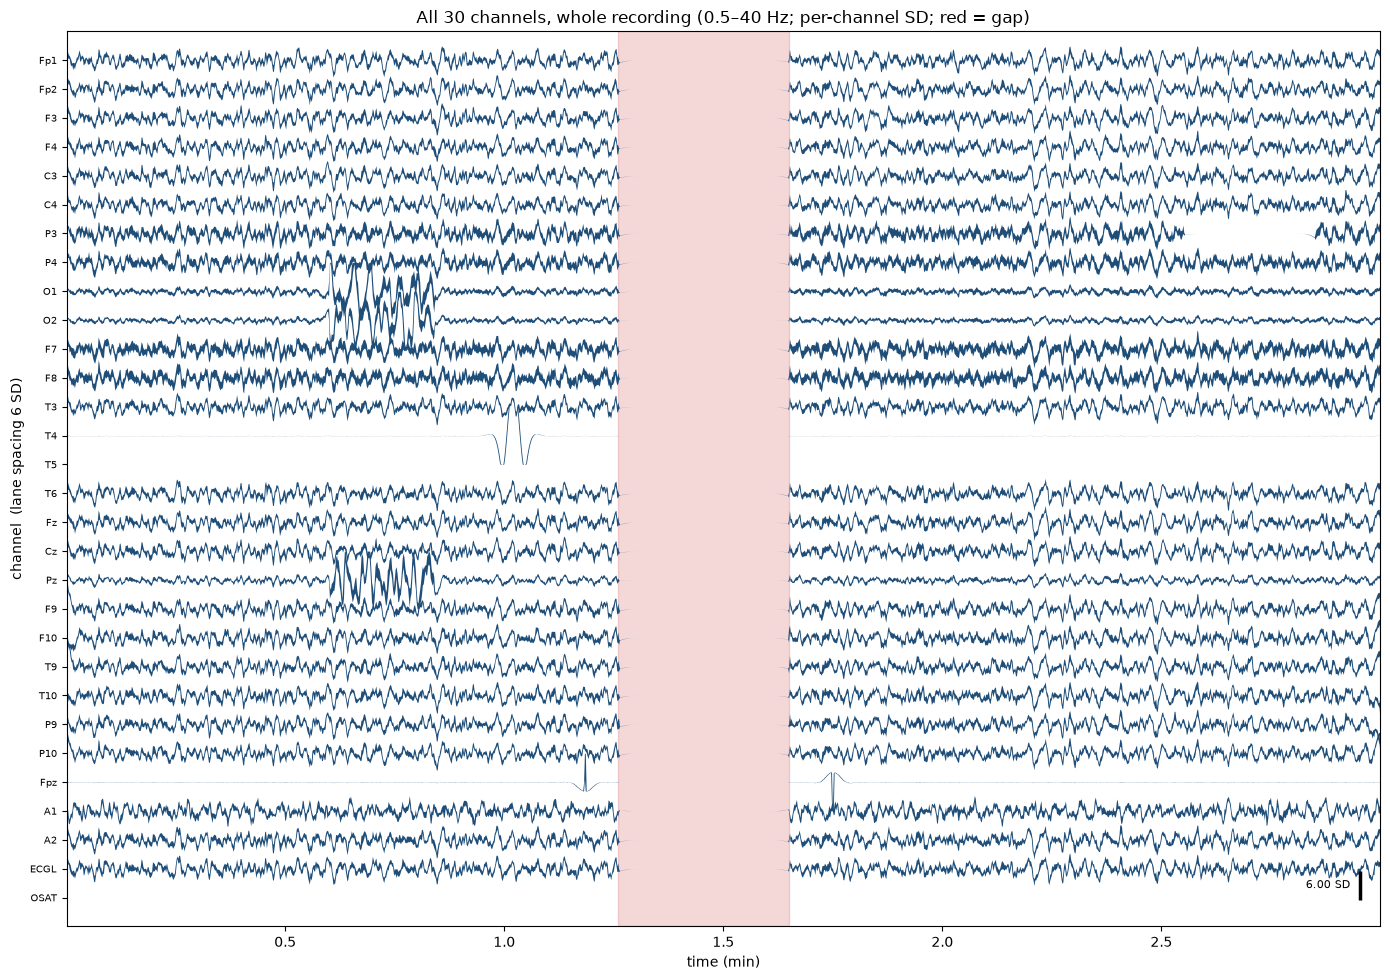

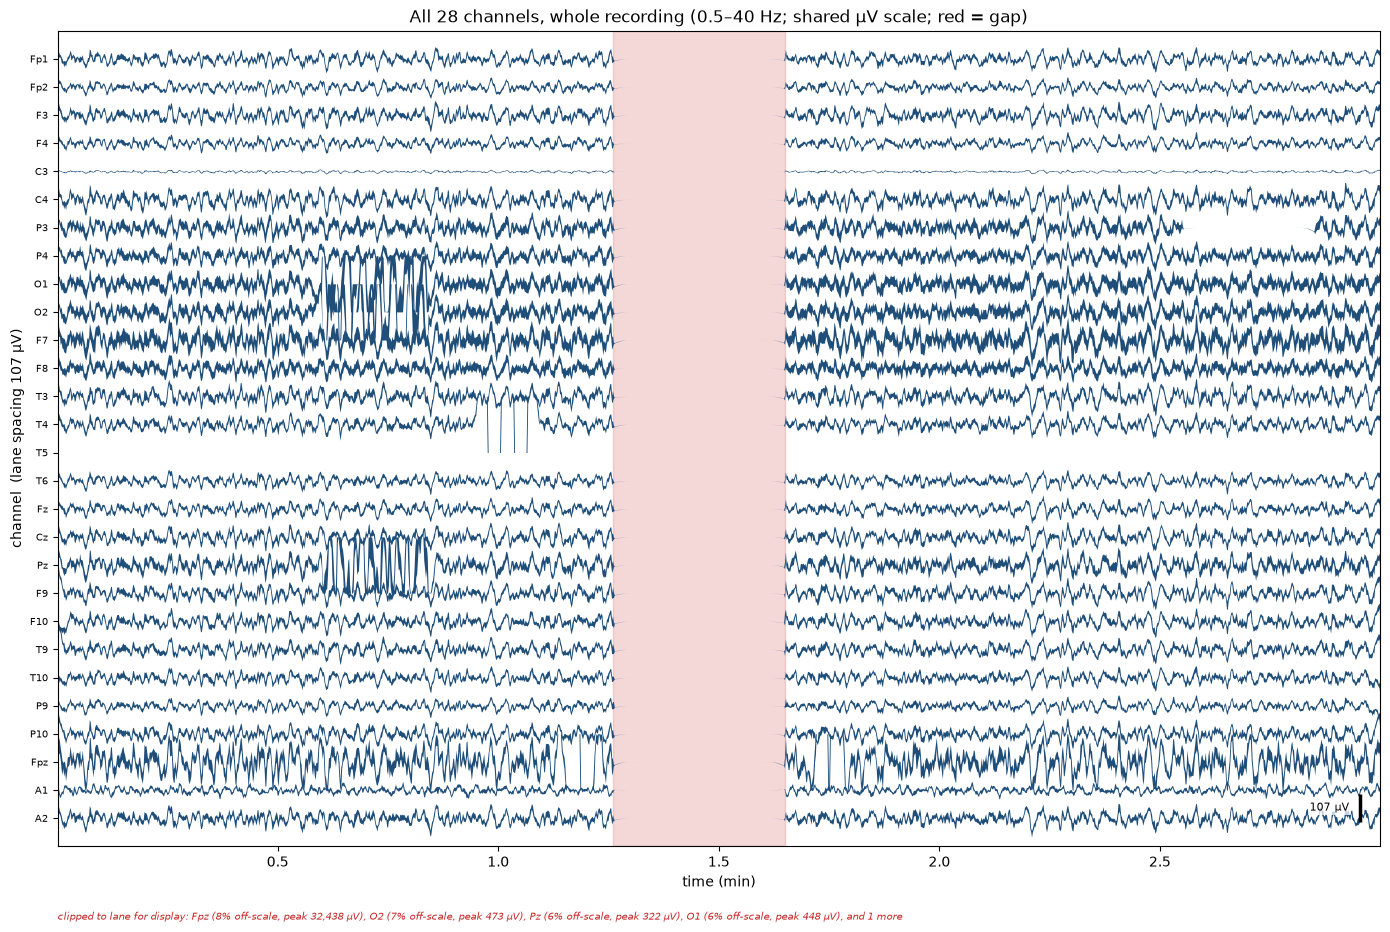

In [3]:
sq.viz.plot_overview(rec)
plt.tight_layout()
plt.show()

# EEG only, on a shared absolute µV scale — amplitudes are comparable here, so
# an attenuated or oversized electrode stands out directly.
sq.viz.plot_overview(rec.pick(ch_type="eeg"), normalize=False)
plt.tight_layout()
plt.show()

## 2. Recording-scope integrity

Signal-agnostic checks: does the data exist, is its clock coherent, can the
channels share one time axis. Kept in their own table rather than broadcast
across every channel row — a gap is a property of the recording.

In [4]:
issues = sq.check_integrity(rec)
issues

,check,severity,t_start,t_end,channel,detail
0,coverage,bad,0.0,180.0,None,13.0% of the timeline has no data
1,dead_channel,bad,0.0,180.0,T5,channel is exactly constant for the whole reco...
2,dead_channel,bad,0.0,180.0,OSAT,channel is exactly constant for the whole reco...
3,irregular_sampling,marginal,2.0,6.0,None,1 packet boundary/ies have a stamp gap larger ...
4,nonmonotonic_time,bad,4.0,2.0,None,1 packet(s) have a sample stamp earlier than t...
5,overlapping_packets,bad,4.0,5.0,None,1 packet(s) start before the previous packet ends
6,data_gap,bad,75.6,99.0,None,23.4 s with no data (13.0% of the recording)


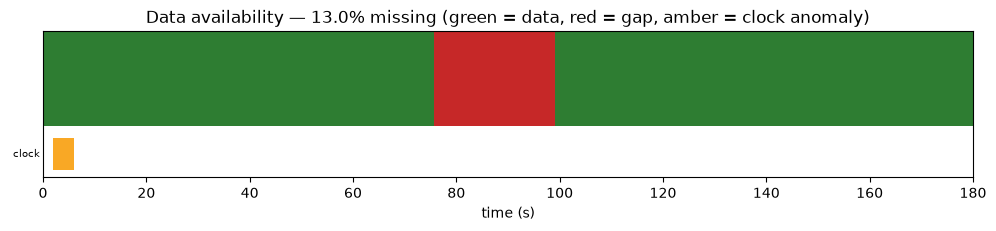

In [5]:
sq.viz.plot_availability(rec, issues)
plt.show()

## 3. Assess

`sq.assess()` runs both scales: 1-second intervals for episodes, and a
whole-recording pass for sustained channel-scope defects. Everything below comes
from this one call, but each piece is available separately if you want to vary
the metrics, the grid, or the thresholds.

Work proceeds block by block: each block loads a padded span, filters it once,
and computes every metric for the intervals inside it. The padding is derived
from the actual filter length, so results are identical to processing the whole
recording at once — verified to ~1e-12 in the test suite.

In [6]:
report = sq.assess(rec, window=WINDOW)
report

<QualityReport 28 channels, 10 with sustained defects, 43 time-localized segments>

In [7]:
print(report.verdicts["verdict"].value_counts().to_dict())
report.channels.head(12).round(1)

{'good': 2891, 'bad': 1395, 'no_data': 644, 'marginal': 110}


,pct_bad,pct_marginal,pct_good,pct_no_data,n_intervals,verdict,reasons
channel,,,,,,,
T5,100.0,0.0,0.0,12.8,180,bad,ISOLATED+FLAT
C3,99.4,0.6,0.0,12.8,180,bad,AMP_OUTLIER
F9,97.5,0.0,2.5,12.8,180,bad,LINE_NOISE
F10,97.5,0.0,2.5,12.8,180,bad,LINE_NOISE
T9,97.5,0.0,2.5,12.8,180,bad,LINE_NOISE
P9,97.5,0.0,2.5,12.8,180,bad,LINE_NOISE
P10,97.5,0.0,2.5,12.8,180,bad,LINE_NOISE
T10,97.5,0.0,2.5,12.8,180,bad,LINE_NOISE
A1,26.1,7.6,66.2,12.8,180,bad,ISOLATED+AMP_OUTLIER


### 3.1 Quality over time

The plot the per-interval design exists to make possible. A per-channel verdict
can only say *which* electrodes are suspect; this says **when** — which is what
distinguishes an intermittent contact from a dead one, and a subject-wide
movement episode from an electrode fault.

`no_data` is its own category, not a shade of "good". Missing data is not
quality.

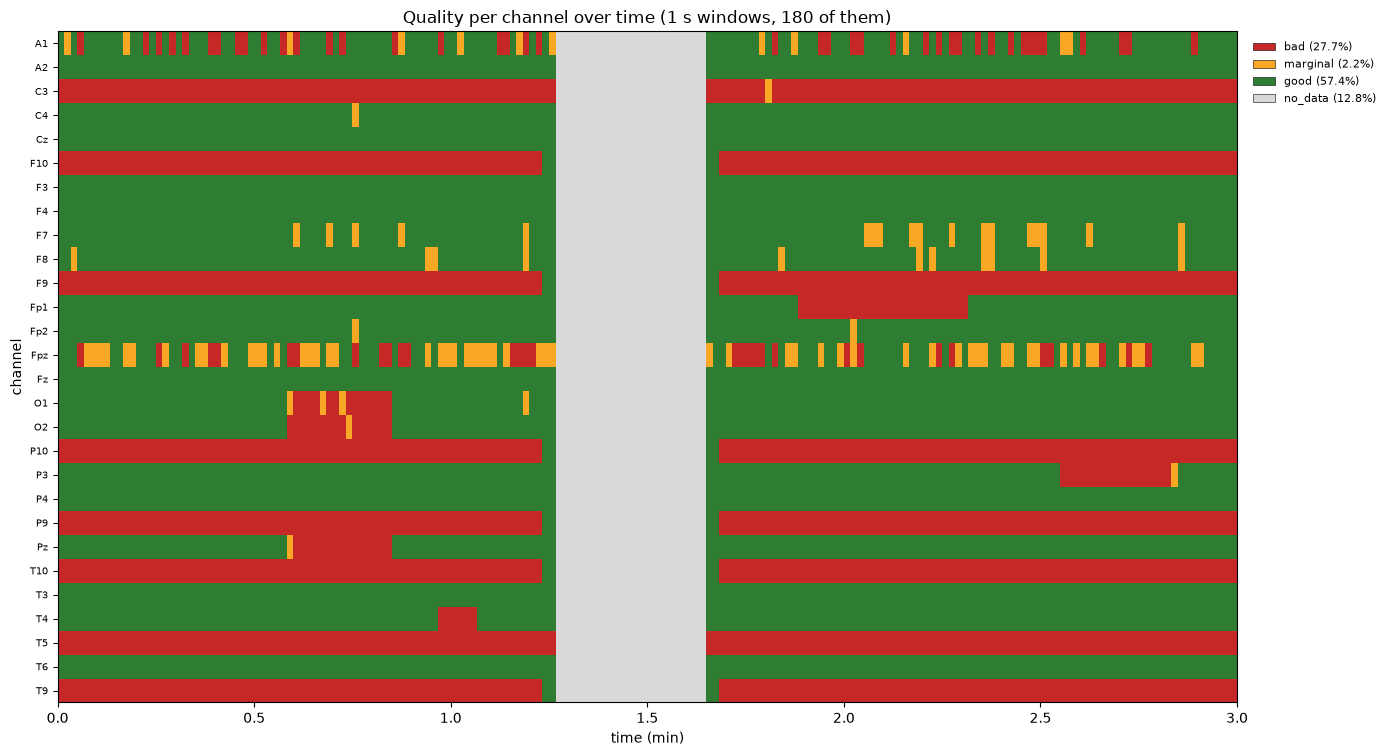

In [8]:
sq.viz.plot_quality_heatmap(report.verdicts, report.metrics)
plt.tight_layout()
plt.show()

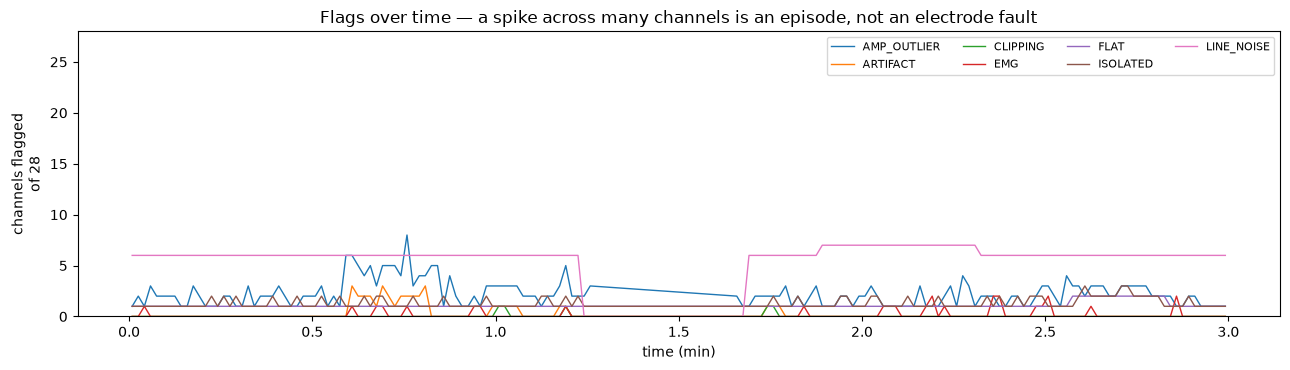

In [9]:
# A spike across many channels at once is an episode, not an electrode fault.
sq.viz.plot_flag_timeline(report.verdicts, report.metrics)
plt.tight_layout()
plt.show()

## 4. What to exclude

Segments, not channels. `scope` says which pass found each one: `channel` for a
sustained defect spanning the recording, `interval` for a bounded episode.

Episodes shorter than `min_duration` (default 2 s) are dropped — a channel
sitting near a threshold crosses it repeatedly from one second to the next, and
that flicker is not a finding.

In [10]:
print(f"channels with a sustained defect: {report.bad_channels}")
print(f"\nsegments: {len(report.segments)}  "
      f"({int((report.segments['scope'] == 'interval').sum())} time-localized)")
report.segments.nlargest(12, "duration").round(1)

channels with a sustained defect: ['A1', 'C3', 'F10', 'F9', 'Fpz', 'P10', 'P9', 'T10', 'T5', 'T9']

segments: 53  (43 time-localized)


,channel,t_start,t_end,duration,severity,reasons,n_intervals,scope
0,A1,0.0,180.0,180.0,bad,ISOLATED,1,channel
1,C3,0.0,180.0,180.0,bad,AMP_OUTLIER,1,channel
2,F10,0.0,180.0,180.0,bad,LINE_NOISE,1,channel
3,F9,0.0,180.0,180.0,bad,LINE_NOISE,1,channel
4,Fpz,0.0,180.0,180.0,bad,AMP_OUTLIER+CLIPPING+ISOLATED,1,channel
5,P10,0.0,180.0,180.0,bad,LINE_NOISE,1,channel
6,P9,0.0,180.0,180.0,bad,LINE_NOISE,1,channel
7,T10,0.0,180.0,180.0,bad,LINE_NOISE,1,channel
8,T5,0.0,180.0,180.0,bad,FLAT+ISOLATED,1,channel
9,T9,0.0,180.0,180.0,bad,LINE_NOISE,1,channel


In [11]:
print("excluded time per channel (s):")
report.excluded_time().head(12).round(0)

excluded time per channel (s):


channel
C3     337.0
T5     337.0
F9     333.0
F10    333.0
P9     333.0
T10    333.0
P10    333.0
T9     333.0
A1     223.0
Fpz    208.0
Fp1     26.0
P3      17.0
Name: duration, dtype: float64

In [12]:
# As MNE annotations, channel-scoped, so a bad stretch on one electrode
# excludes only that electrode downstream rather than the whole epoch.
ann = sq.to_annotations(report.segments)
print(ann)
print("first few:", list(zip(ann.onset[:3].round(1), ann.description[:3], ann.ch_names[:3])))

<Annotations | 53 segments, channel-specific: BAD_AMP_OUTLIER (9), ...>
first few: [(np.float64(0.0), np.str_('BAD_LINE_NOISE'), ('F10',)), (np.float64(0.0), np.str_('BAD_LINE_NOISE'), ('F9',)), (np.float64(0.0), np.str_('BAD_LINE_NOISE'), ('P10',))]


## 5. Scoring against ground truth

Only possible for the synthetic example, and the reason it exists: the generator
records which fault it placed on which channel **and over which time span**, so
detection is measured rather than admired.

Two caveats worth reading. Extra flags on an already-broken channel are not
false positives — a dead electrode genuinely correlates with nothing. And
spectral flags (`LINE_NOISE`, `EMG`) are attributed through a 4-second analysis
window, so their onsets are only accurate to about that window; amplitude flags
are exact to the interval.

In [13]:
if truth is None:
    print("real recording — no ground truth to score against")
else:
    mf, flags = report.metrics, report.flags
    times = mf.table.groupby(level="interval")[["t_start", "t_end"]].first()

    def flags_in(ch, t0, t1):
        f = flags[flags["channel"] == ch]
        if not len(f):
            return set()
        ts = times.reindex(f["interval"])
        hit = (ts["t_end"].to_numpy() > t0) & (ts["t_start"].to_numpy() < t1)
        return set(f["flag"].to_numpy()[hit])

    eeg = set(mf.table.index.get_level_values("channel"))
    rows = []
    for r in truth.itertuples():
        if r.channel not in eeg:
            continue
        got = flags_in(r.channel, r.t_start, r.t_end)
        rows.append(dict(channel=r.channel, window=f"{r.t_start:.0f}-{r.t_end:.0f}s",
                         injected=r.injected, detected="+".join(sorted(got)),
                         caught="yes" if r.injected in got else "NO"))
    score = pd.DataFrame(rows)
    n_ok = int((score["caught"] == "yes").sum())
    print(f"injected faults detected: {n_ok}/{len(score)}")

    faulty = set(truth["channel"])
    clean = sorted(eeg - faulty)
    bad_clean = report.channels.loc[clean]
    print(f"clean channels wrongly condemned: "
          f"{int((bad_clean['verdict'] != 'good').sum())} of {len(clean)}")
    display(score)

injected faults detected: 19/19
clean channels wrongly condemned: 0 of 10


,channel,window,injected,detected,caught
0,A1,0-180s,ISOLATED,AMP_OUTLIER+ISOLATED,yes
1,C3,0-180s,AMP_OUTLIER,AMP_OUTLIER,yes
2,F10,0-180s,LINE_NOISE,LINE_NOISE,yes
3,F7,0-180s,EMG,AMP_OUTLIER+EMG,yes
4,F8,0-180s,EMG,EMG,yes
5,F9,0-180s,LINE_NOISE,LINE_NOISE,yes
6,Fp1,112-140s,LINE_NOISE,LINE_NOISE,yes
7,Fpz,0-180s,AMP_OUTLIER,AMP_OUTLIER+ARTIFACT+CLIPPING+ISOLATED,yes
8,Fpz,0-180s,CLIPPING,AMP_OUTLIER+ARTIFACT+CLIPPING+ISOLATED,yes
9,O1,36-50s,ARTIFACT,AMP_OUTLIER+ARTIFACT+EMG+ISOLATED,yes


### 5.1 Episodes stay inside their episode

The claim per-interval flagging makes: a fault bounded in time must not condemn
the channel's clean stretches.

In [14]:
if truth is not None:
    episodic = truth[(truth["t_start"] > 0) & (truth["t_end"] < rec.duration - 5)]
    ep_seg = report.segments[report.segments["scope"] == "interval"]
    rows = []
    for r in episodic.itertuples():
        s = ep_seg[(ep_seg["channel"] == r.channel)
                   & (ep_seg["t_end"] > r.t_start) & (ep_seg["t_start"] < r.t_end)]
        rows.append(dict(channel=r.channel, injected=r.injected,
                         injected_span=f"{r.t_start:.0f}-{r.t_end:.0f}s",
                         detected_span=(f"{s['t_start'].min():.0f}-{s['t_end'].max():.0f}s"
                                        if len(s) else "MISSED")))
    display(pd.DataFrame(rows))

,channel,injected,injected_span,detected_span
0,Fp1,LINE_NOISE,112-140s,113-139s
1,O1,ARTIFACT,36-50s,36-51s
2,O2,ARTIFACT,36-50s,35-51s
3,P3,FLAT,153-171s,153-170s
4,Pz,ARTIFACT,36-50s,36-51s
5,T4,CLIPPING,59-63s,58-64s


## 6. Where the problems are on the head

`pct_bad` — the fraction of covered time each electrode spent flagged — is the
continuous quantity worth mapping. A binary good/bad label discards the
difference between an electrode that failed for ten seconds and one that never
worked.

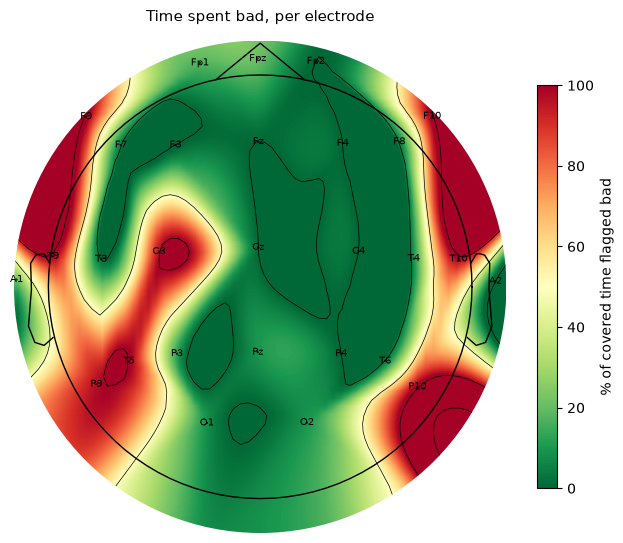

In [15]:
sq.viz.plot_pct_bad_topomap(report.channels)
plt.tight_layout()
plt.show()

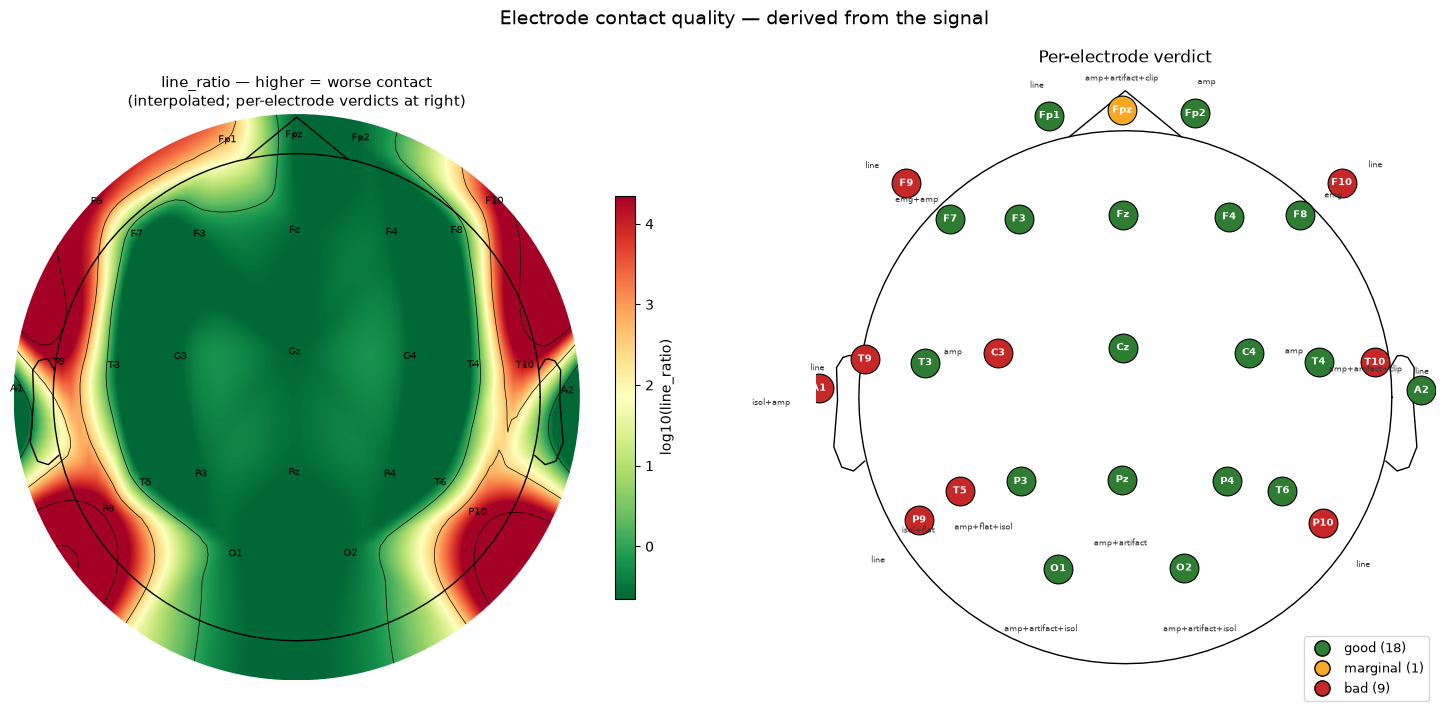

In [16]:
sq.viz.plot_contact_quality(report.whole, report.channels, metric="line_ratio", log=True)
plt.show()

## 7. Evidence for the flags

A table saying a channel has a mains ratio of 11,000 is an assertion; a spectrum
showing its line-frequency spike towering over every clean channel is the
evidence. Check every flag class before acting on it.

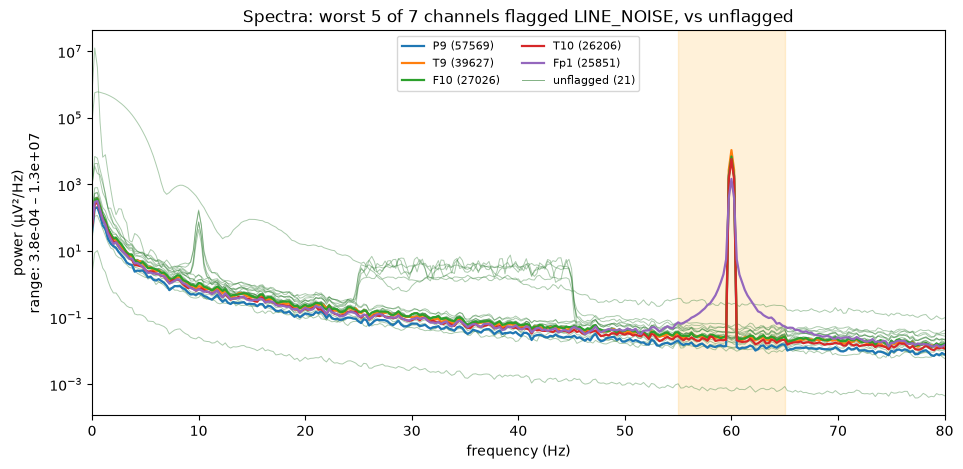

In [17]:
if "LINE_NOISE" in set(report.flags["flag"]):
    sq.viz.plot_good_bad_psd(rec, report.flags, flag="LINE_NOISE")
    plt.show()
else:
    sq.viz.plot_psd_examples(rec, report.metrics, metric="line_ratio")
    plt.show()

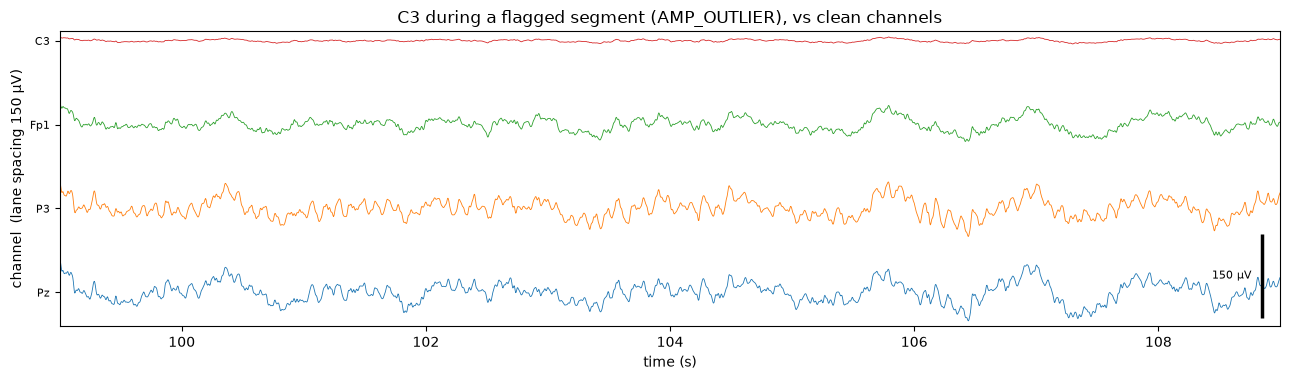

In [18]:
# The raw signal inside a flagged segment, next to a clean channel at the same
# gain — where a "flat" channel that actually has a visible trace gives itself away.
ep = report.segments[report.segments["scope"] == "interval"]
if len(ep):
    worst = ep.nlargest(1, "duration").iloc[0]
    clean = [c for c in report.channels.index[report.channels["verdict"] == "good"]][:3]
    sq.viz.plot_channel_snippet(
        rec, [worst["channel"]] + clean,
        t_start=max(0, worst["t_start"]), duration=min(10.0, worst["duration"]),
        title=f"{worst['channel']} during a flagged segment "
              f"({worst['reasons']}), vs clean channels")
    plt.tight_layout()
    plt.show()

## 8. Summary

In [19]:
bad = report.bad_channels
ep = report.segments[report.segments["scope"] == "interval"]
covered = 100 * rec.covered.mean()

print(f"recording        : {rec}")
print(f"data present     : {covered:.1f}% of the timeline")
print(f"integrity        : {len(report.issues)} finding(s) — "
      f"{sorted(set(report.issues['check'])) if len(report.issues) else 'none'}")
print(f"sustained defects: {len(bad)} channel(s) — {', '.join(bad) if bad else 'none'}")
print(f"episodes         : {len(ep)} segment(s) on {ep['channel'].nunique()} channel(s), "
      f"{ep['duration'].sum() / 60:.1f} min total")
print()
print("Exclude the sustained channels outright; for the rest, exclude the listed")
print("time spans rather than the whole channel:")
display(report.segments[report.segments["scope"] == "interval"]
        .nlargest(8, "duration")[["channel", "t_start", "t_end", "duration", "reasons"]]
        .round(1))

recording        : <Recording 30 ch @ 250 Hz, 3.0 min, 87% covered, counts>
data present     : 87.0% of the timeline
integrity        : 7 finding(s) — ['coverage', 'data_gap', 'dead_channel', 'irregular_sampling', 'nonmonotonic_time', 'overlapping_packets']
sustained defects: 10 channel(s) — A1, C3, F10, F9, Fpz, P10, P9, T10, T5, T9
episodes         : 43 segment(s) on 16 channel(s), 23.3 min total

Exclude the sustained channels outright; for the rest, exclude the listed
time spans rather than the whole channel:


,channel,t_start,t_end,duration,reasons
24,C3,99.0,180.0,81.0,AMP_OUTLIER
50,T5,99.0,180.0,81.0,FLAT+ISOLATED
26,F10,101.0,180.0,79.0,LINE_NOISE
28,F9,101.0,180.0,79.0,LINE_NOISE
41,P10,101.0,180.0,79.0,LINE_NOISE
44,P9,101.0,180.0,79.0,LINE_NOISE
47,T10,101.0,180.0,79.0,LINE_NOISE
52,T9,101.0,180.0,79.0,LINE_NOISE
